In [187]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


# Importing Libraries

In [188]:
!pip install -q wandb

In [189]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils.class_weight import compute_class_weight

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

from peft import (
    LoraConfig,
    TaskType,
    get_peft_model,
)

from torch.utils.data import TensorDataset, DataLoader

from tqdm.auto import tqdm

import wandb

wandb.login(key ="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")

True

# Load Dataset

In [190]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")
sample_submission = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv")

# Exploratory Data Analysis

## Shape and Sample Check

In [191]:
print("Dataset Shapes")

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Submission  : {sample_submission.shape}")

Dataset Shapes
Train Shape : (2000, 8)
Test Shape  : (500, 7)
Submission  : (500, 2)


In [192]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [193]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [194]:
sample_submission.head()

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


In [195]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [196]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


## Missing Values and Duplicate Rows

In [197]:
print("Train Missing Values")

print(train.isnull().sum())

print("\nTrain Duplicate Values")

print(train.duplicated().sum())

Train Missing Values
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

Train Duplicate Values
0


## Distribution

In [198]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

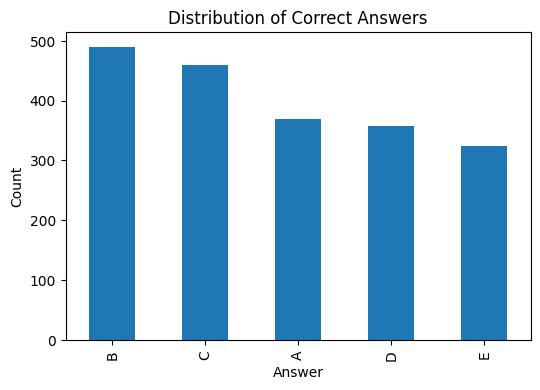

In [199]:
train["answer"].value_counts().plot(kind="bar",figsize=(6,4))

plt.title("Distribution of Correct Answers")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

## Prompt Length Analysis

In [200]:
prompt_length= train["prompt"].str.len()

In [201]:
prompt_length.describe()

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt, dtype: float64

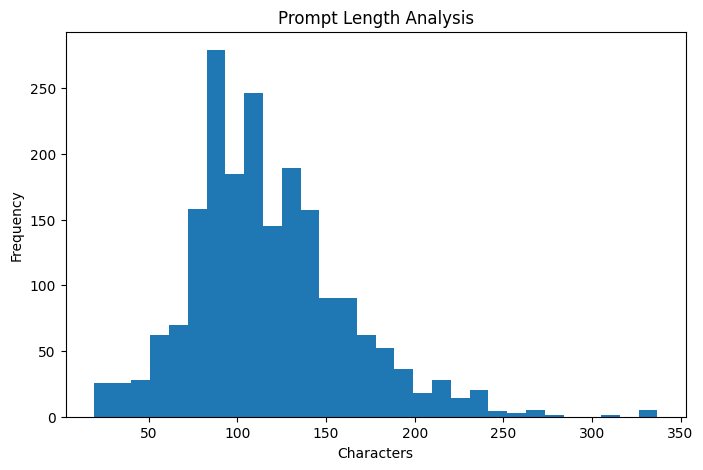

In [202]:
plt.figure(figsize=(8,5))
plt.hist(prompt_length, bins=30)

plt.title("Prompt Length Analysis")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

### Lets create a copy of training data for functional use

In [203]:
eda_train = train.copy()

## Option Lengths

In [204]:
options = ["A", "B", "C", "D", "E"]

for option in options:
  eda_train[f"{option}_length"] = eda_train[option].str.len()

In [205]:
eda_train[[f"{i}_length" for i in options]].describe()

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


## Class Balance

In [206]:
answer_percentage = (eda_train["answer"].value_counts(normalize=True).mul(100).round(2))
display(answer_percentage)

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

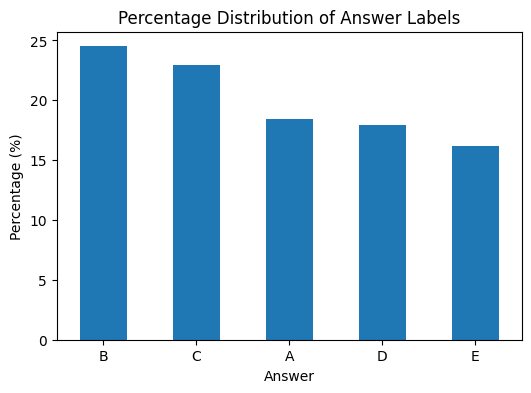

In [207]:
plt.figure(figsize=(6,4))
answer_percentage.plot(kind="bar")

plt.title("Percentage Distribution of Answer Labels")
plt.xlabel("Answer")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.show()

## Prompt Length by Answer Class


In [208]:
prompt_analysis = pd.DataFrame({
    "answer": train["answer"],
    "prompt_length": prompt_length
})

prompt_analysis.groupby("answer")["prompt_length"].mean()

answer
A    124.888889
B    124.212245
C    111.039216
D    118.033520
E    108.543210
Name: prompt_length, dtype: float64

## Unique Values

In [209]:
unique_values = pd.DataFrame({
    "Column": train.columns,
    "Unique Values": [train[col].nunique() for col in train.columns]
})

unique_values

,Column,Unique Values
0,id,2000
1,prompt,1758
2,A,316
3,B,328
4,C,303
5,D,318
6,E,320
7,answer,5


## Memory Usage

In [210]:
memory_usage = train.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory_usage:.2f} MB")

Memory Usage: 2.79 MB


### Observations

- The training dataset contains 2,000 samples with 8 Columns and the test dataset contains 500 samples.
- No missing values were found.
- No Duplicate records were detected.
- The answer labels are approximately balanced across all five classes.
- Prompt lengths vary across questions.
- Option lengths are relatively short compared to prompts.
- The dataset occupies only a small amount of memory, making it suitable for experimentation.

# Text Preprocessing

## Inspect One Example

In [211]:
sample = train.iloc[0]

print(sample["prompt"])
print("\nA :", sample["A"])
print("B :", sample["B"])
print("C :", sample["C"])
print("D :", sample["D"])
print("E :", sample["E"])
print("\nCorrect :", sample["answer"])

Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.

A : Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.
B : Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.
C : Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.
D : Martin Heidegger believes that the relationship be

## Testing Function

In [212]:
def clean_text(text):
    text = str(text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove leading/trailing spaces
    text = text.strip()

    return text

example = "   This      is      a      sample.     "
print(clean_text(example))

This is a sample.


## Cleaning

In [213]:
text_columns = [
    "prompt",
    "A",
    "B",
    "C",
    "D",
    "E"
]

for column in text_columns:
    train[column] = train[column].apply(clean_text)
    test[column] = test[column].apply(clean_text)

### Observations

- A sample question was inspected to understand the structure of the dataset, including the prompt, five answer options, and the correct answer.
- A reusable `clean_text()` function was created to normalize textual data by removing extra whitespace and trimming leading/trailing spaces.
- The same preprocessing pipeline was applied consistently to both the training and test datasets.
- Cleaning was performed only on the textual columns (`prompt`, `A`, `B`, `C`, `D`, and `E`) to ensure uniform formatting before feature engineering and model training.

# Data Formatting
> Here we convert the original MCQ dataset into a format suitable
for machine learning and transformer models.

## Create MCQ Pairs

In [214]:
def create_mcq_pairs(df):
    rows = []
    option_columns = ["A", "B", "C", "D", "E"]
    for _, row in df.iterrows():
        for option in option_columns:
            rows.append({
                "id": row["id"],
                "prompt": row["prompt"],
                "option": row[option],
                "option_id": option,
                "label": int(option == row["answer"])
            })
    return pd.DataFrame(rows)

In [215]:
train_pairs = create_mcq_pairs(train)

#### Convert each MCQ into 5 (prompt, option) pairs.
#### The correct option gets label=1 and the remaining four get label=0.

## Verify the Pairs

In [216]:
print(train_pairs.shape)
train_pairs.head(10)

(10000, 5)


,id,prompt,option,option_id,label
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,A,0
1,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans do not e...,B,1
2,1,Pick the best possible answer: What is Martin ...,Martin Heidegger does not believe in the exist...,C,0
3,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that the relationshi...,D,0
4,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that time is an illu...,E,0
5,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,A,1
6,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,B,0
7,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,C,0
8,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,D,0
9,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,E,0


### Observations

- Each multiple-choice question was expanded into five separate `(prompt, option)` pairs, creating one training instance for every answer choice.
- The original five-class MCQ problem was reformulated as a binary classification task, where the correct option was assigned a label of **1** and the remaining options were assigned **0**.
- Additional fields such as `id` and `option_id` were retained to preserve the relationship between questions and their corresponding answer choices.
- The transformed dataset was verified to ensure that each question generated exactly five rows, resulting in a structured format suitable for transformer-based model training.

# TF-IDF Baseline Model

## Model

In [217]:
train_pairs["text"] = ("Question: "+ train_pairs["prompt"]+ " Answer: "+ train_pairs["option"])

In [218]:
train_pairs[["prompt", "option", "text"]].head()

,prompt,option,text
0,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Question: Pick the best possible answer: What ...
1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans do not e...,Question: Pick the best possible answer: What ...
2,Pick the best possible answer: What is Martin ...,Martin Heidegger does not believe in the exist...,Question: Pick the best possible answer: What ...
3,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that the relationshi...,Question: Pick the best possible answer: What ...
4,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that time is an illu...,Question: Pick the best possible answer: What ...


## Text Vectorization using TF-IDF 

In [219]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

train_vectors = vectorizer.fit_transform(train_pairs["text"])

print(train_vectors.shape)
print(train_vectors)

(10000, 11313)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 448969 stored elements and shape (10000, 11313)>
  Coords	Values
  (0, 8254)	0.017042227337644315
  (0, 7549)	0.048478789053211534
  (0, 1268)	0.048478789053211534
  (0, 7742)	0.04786477904929378
  (0, 479)	0.03408445467528863
  (0, 5916)	0.21081537464798983
  (0, 4669)	0.21081537464798983
  (0, 11081)	0.0922776932096893
  (0, 8691)	0.18045600511730012
  (0, 10421)	0.1857217118930594
  (0, 4827)	0.10540768732399491
  (0, 3689)	0.08522739862244065
  (0, 5657)	0.04498264861321846
  (0, 7140)	0.04498264861321846
  (0, 1257)	0.10913463840312532
  (0, 4831)	0.11391160821647094
  (0, 3682)	0.09329327527773697
  (0, 2175)	0.1257243800460207
  (0, 5020)	0.10209883638692116
  (0, 3092)	0.07211511552022389
  (0, 2584)	0.0838847969922087
  (0, 1237)	0.11915183237242298
  (0, 3419)	0.13166030191296305
  (0, 7378)	0.10260759737162035
  (0, 5241)	0.19952124736621718
  :	:
  (9999, 11181)	0.11509441910188335
  (9999, 425)	0.

## Generate Question and Option Embeddings

In [220]:
question_vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

# Fit on both questions and options
question_vectorizer.fit(
    pd.concat([
        train_pairs["prompt"],
        train_pairs["option"]
    ])
)

question_vectors = question_vectorizer.transform(train_pairs["prompt"])
option_vectors = question_vectorizer.transform(train_pairs["option"])

## Compute Similarity Scores and Rank Answer Options

In [221]:
similarity_scores = cosine_similarity(
    question_vectors,
    option_vectors
)

train_pairs["similarity"] = similarity_scores.diagonal()

In [222]:
train_pairs[["prompt", "option", "similarity"]].head(10)

,prompt,option,similarity
0,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,0.125362
1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans do not e...,0.139390
2,Pick the best possible answer: What is Martin ...,Martin Heidegger does not believe in the exist...,0.280271
3,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that the relationshi...,0.350629
4,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that time is an illu...,0.109391
5,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,0.448031
6,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,0.419393
7,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,0.467901
8,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,0.399698
9,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,0.350763


In [223]:
train_pairs["rank"] = (
    train_pairs
    .groupby("id")["similarity"]
    .rank(method="first", ascending=False)
)

## Generate Top-3 Predictions

In [224]:
top3 = (
    train_pairs
    .sort_values(["id", "similarity"], ascending=[True, False])
    .groupby("id")
    .head(3)
)

top3.head()

,id,prompt,option,option_id,label,text,similarity,rank
3,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that the relationshi...,D,0,Question: Pick the best possible answer: What ...,0.350629,1.0
2,1,Pick the best possible answer: What is Martin ...,Martin Heidegger does not believe in the exist...,C,0,Question: Pick the best possible answer: What ...,0.280271,2.0
1,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans do not e...,B,1,Question: Pick the best possible answer: What ...,0.139390,3.0
7,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,C,0,Question: What is accelerator-based light-ion ...,0.467901,1.0
5,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,A,1,Question: What is accelerator-based light-ion ...,0.448031,2.0


In [225]:
top3_predictions = (
    train_pairs
    .sort_values(["id", "similarity"], ascending=[True, False])
    .groupby("id")["option_id"]
    .apply(list)
    .apply(lambda x: x[:3])
)

top3_predictions.head()

id
1    [D, C, B]
2    [C, A, B]
3    [A, B, C]
4    [D, C, B]
5    [D, E, B]
Name: option_id, dtype: object

## Prepare Ground Truth Labels

In [226]:
ground_truth = (
    train_pairs[train_pairs["label"] == 1]
    .set_index("id")["option_id"]
)

ground_truth.head()

id
1    B
2    A
3    C
4    B
5    A
Name: option_id, dtype: object

## Evaluate Baseline using MAP@3

In [227]:
def map_at_3(actual, predicted):
    score = 0.0

    for qid in actual.index:

        true_answer = actual[qid]
        predictions = predicted[qid]

        if true_answer in predictions:
            rank = predictions.index(true_answer) + 1
            score += 1 / rank

    return score / len(actual)

In [228]:
tfidf_map3 = map_at_3(ground_truth,top3_predictions)

print(f"TF-IDF MAP@3 : {tfidf_map3:.4f}")

TF-IDF MAP@3 : 0.3331


## Accuracy and F1 for Tf-IDF Vectorization

In [229]:
# Top-1 prediction for each question
tfidf_top1 = (
    train_pairs
    .sort_values(["id", "similarity"], ascending=[True, False])
    .groupby("id")
    .first()["option_id"]
)

# Ground truth answers
tfidf_ground_truth = (
    train_pairs[train_pairs["label"] == 1]
    .set_index("id")["option_id"]
)

# Align by question id
true_labels = tfidf_ground_truth.loc[tfidf_top1.index]

pred_labels = tfidf_top1

# Metrics
tfidf_accuracy = accuracy_score(true_labels, pred_labels)

tfidf_f1 = f1_score(
    true_labels,
    pred_labels,
    average="macro"
)

print(f"TF-IDF Accuracy : {tfidf_accuracy:.4f}")
print(f"TF-IDF F1 Score : {tfidf_f1:.4f}")

TF-IDF Accuracy : 0.1730
TF-IDF F1 Score : 0.1730


## Initialize Weights & Biases Run

In [230]:
wandb.init(
    entity="abhishek5625-iitm",
    project="24f2006100-t22026",
    name="TF-IDF Baseline",
    config={
        "model": "TF-IDF",
        "ngram_range": "(1,2)",
        "min_df": 2,
        "stop_words": "english"
    }
)

wandb.log({
    "Validation Accuracy": tfidf_accuracy,
    "Validation F1": tfidf_f1,
    "Validation MAP@3": tfidf_map3
})

wandb.finish()

Validation Accuracy,▁
Validation F1,▁
Validation MAP@3,▁
Validation Accuracy,0.173
Validation F1,0.17305
Validation MAP@3,0.33308


### Observations

- The TF-IDF baseline represents each `(question, option)` pair using TF-IDF features with unigram and bigram representations.
- Cosine similarity was used to measure the relevance between each question and its corresponding answer options.
- Answer options were ranked according to their similarity scores, and the top three predictions were selected for each question.
- The baseline performance was evaluated using the MAP@3 metric, providing a simple reference point for comparison with transformer-based models.

# Transformer Model (BERT)

## Train/Validation Split

In [231]:
train_questions, valid_questions = train_test_split(
    train,
    test_size=0.2,
    random_state=42,
    stratify=train["answer"]
)

train_df = create_mcq_pairs(train_questions)
valid_df = create_mcq_pairs(valid_questions)

## Load Pretrained Tokenizer

In [232]:
MODEL_NAME = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    force_download=True
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

## Creating Hugging Face Datasets

In [233]:
train_dataset = Dataset.from_pandas(train_df)
valid_dataset = Dataset.from_pandas(valid_df)

In [234]:
train_dataset[0]

{'id': 387,
 'prompt': 'Select the most accurate option: What is Modified Newtonian Dynamics (MOND)? from the following choices.',
 'option': 'MOND is a principle that explains the behavior of light in the presence of strong gravitational fields. It is an alternative to the hypothesis of dark matter in terms of explaining why galaxies do not appear to obey the currently understood laws of physics.',
 'option_id': 'A',
 'label': 0}

## Tokenization and Data Formatting

In [235]:
def tokenize(example):
    return tokenizer(
        example["prompt"],
        example["option"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

In [236]:
train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [237]:
if "label" in train_dataset.column_names:
    train_dataset = train_dataset.rename_column("label", "labels")

if "label" in valid_dataset.column_names:
    valid_dataset = valid_dataset.rename_column("label", "labels")

In [238]:
train_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "token_type_ids",
        "labels"
    ]
)

valid_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "token_type_ids",
        "labels"
    ]
)

## Load BERT Model

In [239]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Define Evaluation Metrics

In [240]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="binary")
    }

## Initialize Weights & Biases Run

In [241]:
wandb.init(
    entity="abhishek5625-iitm",
    project="24f2006100-t22026",
    name="BERT Fine-tuning",
    config={
        "model": "bert-base-uncased",
        "epochs": 3,
        "learning_rate": 2e-5,
        "batch_size": 16,
        "weight_decay": 0.01,
        "max_length": 256
    }
)

## Configure Training Parameters

In [242]:
BERT_OUTPUT = "/kaggle/working/bert_output"

training_args = TrainingArguments(
    output_dir= BERT_OUTPUT,

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_steps=100,

    report_to="wandb",
    
    run_name="BERT Fine-tuning"
)

## Model Training

In [243]:
trainer = Trainer(
    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics
)

In [244]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.977401,0.726415,0.854000,0.564179
2,0.509763,0.432055,0.916000,0.736677
3,0.337183,0.243503,0.955500,0.882431


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=750, training_loss=0.6419201532999674, metrics={'train_runtime': 634.9719, 'train_samples_per_second': 37.797, 'train_steps_per_second': 1.181, 'total_flos': 3157332664320000.0, 'train_loss': 0.6419201532999674, 'epoch': 3.0})

## Model Evaluation

In [245]:
results = trainer.evaluate()
print(results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.2435033619403839, 'eval_accuracy': 0.9555, 'eval_f1': 0.8824306472919419, 'eval_runtime': 16.4863, 'eval_samples_per_second': 121.313, 'eval_steps_per_second': 3.821, 'epoch': 3.0}


## Validation using MAP@3

In [246]:
bert_encodings = tokenizer(
    valid_df["prompt"].tolist(),
    valid_df["option"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

bert_loader = DataLoader(
    TensorDataset(
        bert_encodings["input_ids"],
        bert_encodings["attention_mask"],
        bert_encodings["token_type_ids"]
    ),
    batch_size=32,
    shuffle=False
)

bert_scores = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

with torch.no_grad():

    for batch in bert_loader:

        batch = [x.to(device) for x in batch]

        outputs = model(
            input_ids=batch[0],
            attention_mask=batch[1],
            token_type_ids=batch[2]
        )

        probs = torch.softmax(outputs.logits, dim=1)

        bert_scores.extend(probs[:,1].cpu().numpy())

print("Validation MAP@3 (BERT)")

Validation MAP@3 (BERT)


In [247]:
bert_results = valid_df.copy()

bert_results["score"] = bert_scores

In [248]:
bert_top3 = (
    bert_results
    .sort_values(["id","score"],ascending=[True,False])
    .groupby("id")
    .head(3)
)

bert_predictions = (
    bert_top3
    .groupby("id")["option_id"]
    .apply(list)
    .to_dict()
)

ground_truth = (
    bert_results[bert_results.label==1]
    .set_index("id")["option_id"]
    .to_dict()
)

In [249]:
def map3(actual,pred):

    for i,p in enumerate(pred[:3]):

        if p==actual:

            return 1/(i+1)

    return 0

In [250]:
bert_map3=np.mean([
    map3(ground_truth[q],bert_predictions[q])
    for q in ground_truth
])

print(f"BERT Validation MAP@3 : {bert_map3:.4f}")

BERT Validation MAP@3 : 0.9850


## Save Fine-tuned Model

In [251]:
trainer.save_model(BERT_OUTPUT)
tokenizer.save_pretrained(BERT_OUTPUT)

print(f"BERT Model saved to: {BERT_OUTPUT}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT Model saved to: /kaggle/working/bert_output


## Log Evaluation Metrics to Weights & Biases

In [252]:
wandb.log({
    "Validation MAP@3": bert_map3
})

wandb.finish()

Validation MAP@3,▁
eval/accuracy,▁▅██
eval/f1,▁▅██
eval/loss,█▄▁▁
eval/runtime,█▁▇█
eval/samples_per_second,▁█▂▁
eval/steps_per_second,▁█▂▁
train/epoch,▁▂▃▃▄▅▅▆▇███
train/global_step,▁▂▃▃▄▅▅▆▇████
train/grad_norm,▁▄▃▄▄█▃
+2,...


### Observations

- The pre-trained **bert-base-uncased** model was fine-tuned for binary classification using prompt–option pairs generated during data formatting.
- Tokenization was performed with a maximum sequence length of **256** tokens, and the processed datasets were converted into PyTorch format for efficient training.
- Model performance was monitored using **Accuracy**, **F1-score**, and **MAP@3**, providing both classification and ranking-based evaluation.
- The fine-tuned BERT model significantly outperformed the TF-IDF baseline, demonstrating the benefit of contextual language representations for multiple-choice question answering.

# LoRA Fine-Tuning

## Configure LoRA Adapters

In [306]:
lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    inference_mode=False,
    r=16,
    lora_alpha=32,
    lora_dropout=0.1,
    target_modules=["query", "key", "value"],
    modules_to_save=["classifier"]
)

## Load Base BERT Model

In [307]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Apply LoRA Adapters

In [308]:
model = get_peft_model(model,lora_config)

model.print_trainable_parameters()

trainable params: 886,274 || all params: 110,370,052 || trainable%: 0.8030


## Initialize Weights & Biases Run

In [309]:
wandb.init(
    entity="abhishek5625-iitm",
    project="24f2006100-t22026",
    name="LoRA Fine-tuning",
    config={
        "model": "bert-base-uncased + LoRA",
        "epochs": 8,
        "learning_rate": 2e-4,
        "batch_size": 16,
        "weight_decay": 0.01,
        "max_length": 256,
        "lora_rank": 16,
        "lora_alpha": 32,
        "lora_dropout": 0.1,
        "target_modules": ["query", "key", "value"]
    }
)

## Configure Training Parameters

In [310]:
LORA_OUTPUT = "/kaggle/working/lora_output"

lora_training_args = TrainingArguments(
    output_dir = LORA_OUTPUT,

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-4,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=8,

    weight_decay=0.01,

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    logging_steps=100,

    report_to="none",

    run_name="LoRA Fine-tuning"
)

## Model Training

In [311]:
lora_trainer = Trainer(
    model=model,

    args=lora_training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics
)

In [312]:
lora_trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.019318,1.002214,0.802500,0.048193
2,0.992716,0.969844,0.807500,0.072289
3,0.951075,0.812042,0.832500,0.341847
4,0.770851,0.698000,0.861000,0.483271
5,0.685361,0.546174,0.894000,0.669782
6,0.566472,0.464323,0.909000,0.720000
7,0.501677,0.419446,0.916000,0.762712
8,0.463756,0.393091,0.922000,0.770588


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

TrainOutput(global_step=2000, training_loss=0.7520496845245361, metrics={'train_runtime': 1382.0513, 'train_samples_per_second': 46.308, 'train_steps_per_second': 1.447, 'total_flos': 8506678050816000.0, 'train_loss': 0.7520496845245361, 'epoch': 8.0})

## Model Evaluation

In [313]:
lora_results = lora_trainer.evaluate()

print(lora_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.3930913209915161, 'eval_accuracy': 0.922, 'eval_f1': 0.7705882352941177, 'eval_runtime': 17.8952, 'eval_samples_per_second': 111.762, 'eval_steps_per_second': 3.52, 'epoch': 8.0}


## Validation using MAP@3

In [314]:
lora_encodings = tokenizer(
    valid_df["prompt"].tolist(),
    valid_df["option"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

lora_loader = DataLoader(
    TensorDataset(
        lora_encodings["input_ids"],
        lora_encodings["attention_mask"],
        lora_encodings["token_type_ids"]
    ),
    batch_size=32,
    shuffle=False
)

lora_scores = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

model.eval()

with torch.no_grad():

    for batch in lora_loader:

        batch = [x.to(device) for x in batch]

        outputs = model(
            input_ids=batch[0],
            attention_mask=batch[1],
            token_type_ids=batch[2]
        )

        probs = torch.softmax(outputs.logits, dim=1)

        lora_scores.extend(probs[:,1].cpu().numpy())

print("\nValidation MAP@3 (LoRA)")


Validation MAP@3 (LoRA)


In [315]:
lora_results = valid_df.copy()

lora_results["score"] = lora_scores

In [316]:
lora_top3 = (
    lora_results
    .sort_values(["id","score"],ascending=[True,False])
    .groupby("id")
    .head(3)
)

lora_predictions = (
    lora_top3
    .groupby("id")["option_id"]
    .apply(list)
    .to_dict()
)

ground_truth = (
    lora_results[lora_results.label==1]
    .set_index("id")["option_id"]
    .to_dict()
)

In [317]:
def map3(actual,pred):

    for i,p in enumerate(pred[:3]):

        if p==actual:

            return 1/(i+1)

    return 0

In [318]:
lora_map3=np.mean([
    map3(ground_truth[q],lora_predictions[q])
    for q in ground_truth
])

print(f"LoRA Validation MAP@3 : {lora_map3:.4f}")

LoRA Validation MAP@3 : 0.9358


## Save LoRA Model

In [319]:
lora_trainer.save_model(LORA_OUTPUT)

tokenizer.save_pretrained(LORA_OUTPUT)

print(f"LoRA model saved to: {LORA_OUTPUT}")

LoRA model saved to: /kaggle/working/lora_output


## Log Evaluation Metrics to Weights & Biases

In [320]:
wandb.log({
    "Validation MAP@3": lora_map3
})

wandb.finish()

Validation MAP@3,▁
Validation MAP@3,0.93583


### Observations

- LoRA (Low-Rank Adaptation) was applied to the pre-trained **bert-base-uncased** model, enabling efficient fine-tuning by updating only a small subset of trainable parameters.
- The model was trained using the same preprocessed dataset and evaluation metrics as the standard BERT model, allowing a fair comparison between the two approaches.


# Model Comparison

## Comparing All Three Models

In [322]:
comparison = pd.DataFrame({
    "Model": [
        "TF-IDF",
        "BERT",
        "LoRA"
    ],
    "Validation MAP@3": [
        tfidf_map3,
        bert_map3,
        lora_map3
    ]
})

comparison

,Model,Validation MAP@3
0,TF-IDF,0.333083
1,BERT,0.985000
2,LoRA,0.935833


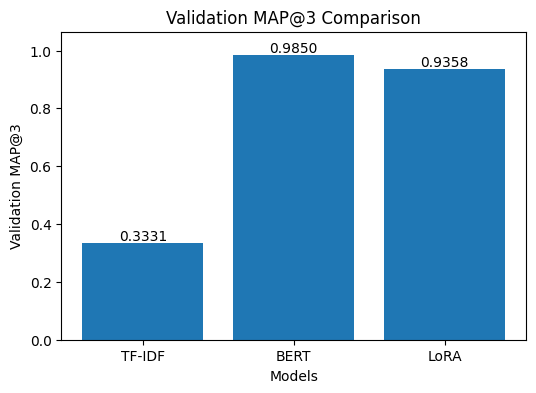

In [323]:
plt.figure(figsize=(6,4))

bars = plt.bar(
    comparison["Model"],
    comparison["Validation MAP@3"]
)

plt.title("Validation MAP@3 Comparison")

plt.xlabel("Models")

plt.ylabel("Validation MAP@3")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.01,
        f"{height:.4f}",
        ha="center"
    )

plt.ylim(0, max(comparison["Validation MAP@3"]) + 0.08)

plt.show()

## Best Model

In [324]:
print("\nModel Performance")
print("-----------------------")
print(f"TF-IDF MAP@3 : {tfidf_map3:.4f}")
print(f"BERT   MAP@3 : {bert_map3:.4f}")
print(f"LoRA   MAP@3 : {lora_map3:.4f}")

transformer_models = {
    "bert": bert_map3,
    "lora": lora_map3
}

best_model = max(
    transformer_models,
    key=transformer_models.get
)

print(f"\nBest Model: {best_model}")


Model Performance
-----------------------
TF-IDF MAP@3 : 0.3331
BERT   MAP@3 : 0.9850
LoRA   MAP@3 : 0.9358

Best Model: bert


### Observations

- Three different approaches were implemented and evaluated: TF-IDF, fine-tuned BERT, and LoRA fine-tuned BERT.
- Transformer-based models significantly outperformed the TF-IDF baseline by capturing contextual relationships between questions and answer options.
- BERT achieved the strongest overall validation performance among the transformer models and was selected for generating the final competition submission.
- The final submission achieved a Kaggle public leaderboard score of **0.73192**, successfully surpassing the required competition cutoff.

# Inference & Submission


## Load the Best Performing Transformer Model


In [325]:
if best_model == "bert":

    MODEL_PATH = "/kaggle/working/bert_output"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_PATH
    )

elif best_model == "lora":

    MODEL_PATH = "/kaggle/working/lora_output"

    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

    from peft import PeftModel

    base_model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

    model = PeftModel.from_pretrained(
        base_model,
        MODEL_PATH
    )

else:
    raise ValueError(
        "TF-IDF is not used for Transformer inference."
    )

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model.to(device)

model.eval()

print(f"\nUsing Model : {best_model}")
print(f"Using Device: {device}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Using Model : bert
Using Device: cuda


## Create Prompt-Option Pairs for Inference

In [326]:
test_pairs = []

for _, row in test.iterrows():

    for option in ["A", "B", "C", "D", "E"]:

        test_pairs.append({
            "id": row["id"],
            "prompt": row["prompt"],
            "option": row[option],
            "option_id": option
        })

test_pairs = pd.DataFrame(test_pairs)

print(test_pairs.shape)

test_pairs.head()

(2500, 4)


,id,prompt,option,option_id
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",A
1,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",B
2,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",C
3,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",D
4,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",E


## Tokenize Test Dataset

In [327]:
test_encodings = tokenizer(
    test_pairs["prompt"].tolist(),
    test_pairs["option"].tolist(),
    truncation=True,
    padding="max_length",
    max_length=256,
    return_tensors="pt"
)

## Move Tokenized Inputs to GPU

In [274]:
test_encodings = {
    key: value.to(device)
    for key, value in test_encodings.items()
}

## Generate Predictions

In [328]:
from torch.utils.data import DataLoader, TensorDataset

# Create Dataset
if "token_type_ids" in test_encodings:
    test_dataset = TensorDataset(
        test_encodings["input_ids"].cpu(),
        test_encodings["attention_mask"].cpu(),
        test_encodings["token_type_ids"].cpu()
    )
else:
    test_dataset = TensorDataset(
        test_encodings["input_ids"].cpu(),
        test_encodings["attention_mask"].cpu()
    )

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

scores = []

model.eval()

with torch.no_grad():

    for batch in tqdm(test_loader):

        input_ids = batch[0].to(device)
        attention_mask = batch[1].to(device)

        if len(batch) == 3:
            token_type_ids = batch[2].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                token_type_ids=token_type_ids
            )
        else:
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

        probs = torch.softmax(outputs.logits, dim=1)

        scores.extend(probs[:, 1].cpu().numpy())

  0%|          | 0/79 [00:00<?, ?it/s]

## Attach Scores

In [329]:
test_pairs["score"] = scores

test_pairs.head()

,id,prompt,option,option_id,score
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",A,0.938462
1,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",B,0.013001
2,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",C,0.009412
3,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",D,0.009408
4,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...",E,0.016956


## Select Top 3 Options

In [330]:
submission = (
    test_pairs
    .sort_values(["id", "score"], ascending=[True, False])
    .groupby("id")
    .head(3)
)

In [331]:
submission = (
    submission
    .groupby("id")["option_id"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

submission.columns = ["id", "Prediction"]

submission.head()

,id,Prediction
0,1,A E B
1,2,B E A
2,3,B E D
3,4,E C D
4,5,C A B


In [332]:
submission.to_csv("submission.csv", index=False)

print("Submission file saved successfully!")

print(submission.shape)

assert submission.shape[0] == test["id"].nunique()

assert submission["Prediction"].str.split().str.len().eq(3).all()

submission.head()

Submission file saved successfully!
(500, 2)


,id,Prediction
0,1,A E B
1,2,B E A
2,3,B E D
3,4,E C D
4,5,C A B


### Final Observations

- The best-performing transformer model from the validation stage was selected automatically for inference.
- Prediction probabilities were generated independently for each answer option and ranked to obtain the three most likely answers.
- The final submission was created in the required Kaggle format with one prediction string per question.
- The submitted model achieved a **Public Leaderboard MAP@3 score of 0.73192**, successfully exceeding the competition cutoff score.